# Create a figure showing the frame transformations and noise reductions in second order phase mod ccd


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet



In [2]:
steel_blue, plum = "#4682B4", "#B44682"

In [3]:
initial_state = np.array([1+0j, 0+0j])# |0> state
down_state= np.array([0+0j, 1+0j]) # |1> state
# initial_state = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) # |+> state

# Lab

In [4]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


tol = 10**-7
evaluation_points = 2000
evaluation_time = 4/rabi_freq 

times, states_lab = qt.evolve_state(initial_state, evaluation_time, evaluation_points,  hamiltonians.ccd_lab, 
                natural_freq = natural_freq,
                driving_freq = driving_freq,
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                phase_freq = phase_freq,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)


times, states_lab_down = qt.evolve_state(down_state, evaluation_time, evaluation_points,  hamiltonians.ccd_lab, 
                natural_freq = natural_freq,
                driving_freq = driving_freq,
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                phase_freq = phase_freq,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)




# First

In [5]:
times, states_first = qt.evolve_state(initial_state, evaluation_time, evaluation_points,  hamiltonians.ccd_rwa, 
                natural_freq = natural_freq,
                driving_freq = driving_freq,
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                phase_freq = phase_freq,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)

# Second

In [6]:
times, states_second = qt.evolve_state(initial_state, evaluation_time, evaluation_points,  hamiltonians.ccd_second_frame, 
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)

# Combined

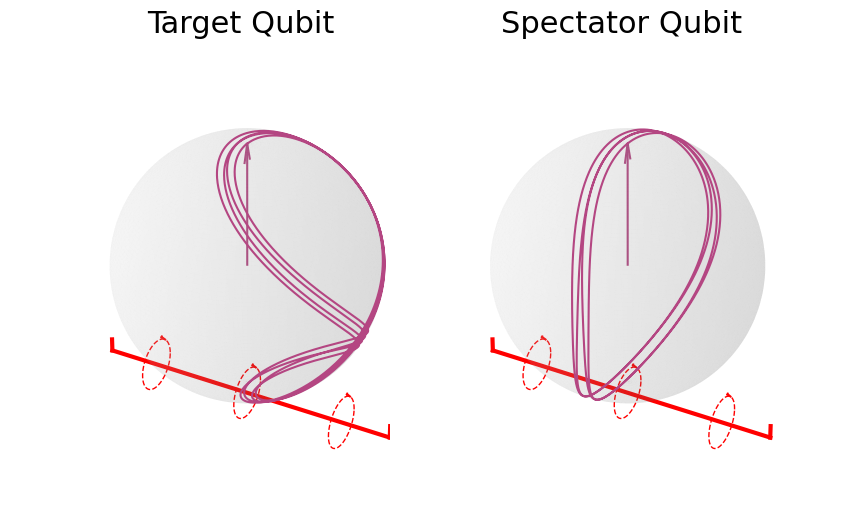

In [ ]:
from matplotlib.patches import FancyArrowPatch

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(18, 6))

# Define the coordinates for the Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=-0.4)  # Very tight spacing

ax1 = fig.add_subplot(gs[0], projection='3d')
ax2 = fig.add_subplot(gs[1], projection='3d')


# Draw Bloch sphere wireframe for each subplot
for ax in [ax1, ax2]:
    ax.plot_surface(x, y, z, rstride=1, cstride=1, color='lightgrey', alpha=0.1, linewidth=0)
    ax.grid(False)  # Disable background grid
    ax.set_axis_off()  # Remove axes
    ax.set_xlim([-1.0, 1.0])
    ax.set_ylim([-1.0, 1.0])
    ax.set_zlim([-1.0, 1.0])
    ax.set_box_aspect([1, 1, 1])  



# Recalculate the trajectories for the three states
x_expectation_lab = np.real(qt.calculate_expectations(states_lab, sigma_x))
y_expectation_lab = np.real(qt.calculate_expectations(states_lab, sigma_y))
z_expectation_lab = np.real(qt.calculate_expectations(states_lab, sigma_z))
x_expectation_lab_down = np.real(qt.calculate_expectations(states_lab_down, sigma_x))
y_expectation_lab_down = np.real(qt.calculate_expectations(states_lab_down, sigma_y))
z_expectation_lab_down = np.real(qt.calculate_expectations(states_lab_down, sigma_z))

x_expectation_first = np.real(qt.calculate_expectations(states_first, sigma_x))
y_expectation_first = np.real(qt.calculate_expectations(states_first, sigma_y))
z_expectation_first = np.real(qt.calculate_expectations(states_first, sigma_z))

# Plot the trajectories on each Bloch sphere
ax1.plot(x_expectation_lab, y_expectation_lab, z_expectation_lab, color=steel_blue, zorder=10)
ax1.quiver(0, 0, 0, x_expectation_lab[-1], y_expectation_lab[-1], z_expectation_lab[-1],
          arrow_length_ratio=0.15, color=steel_blue, zorder=9)
# ax1.plot(x_expectation_lab_down, y_expectation_lab_down, z_expectation_lab_down, color=steel_blue, zorder=10)
# ax1.quiver(0, 0, 0, x_expectation_lab_down[-1], y_expectation_lab_down[-1], z_expectation_lab_down[-1],
#           arrow_length_ratio=0.15, color=steel_blue, zorder=9)

ax2.plot(x_expectation_first, y_expectation_first, z_expectation_first, color=plum, zorder=10)
ax2.quiver(0, 0, 0, x_expectation_first[-1], y_expectation_first[-1], z_expectation_first[-1],
          arrow_length_ratio=0.15, color=plum, zorder=9)



# add titles
ax1.set_title("Target Qubit", fontsize=22)
ax2.set_title("Spectator Qubit", fontsize=22)

# --- Add horizontal ESR antenna + small-radius loops + end-connectors ---
for ax in [ax1, ax2]:
    # 1) Red “wire” along x-axis under the sphere
    x_wire = np.linspace(-1.2, 1.2, 200)
    y_wire = np.zeros_like(x_wire)
    z_wire = np.full_like(x_wire, -1.1)   # just below the sphere
    ax.plot(x_wire, y_wire, z_wire,
            color='red', linewidth=3,
            label='ESR antenna')

    # 2) Tiny red loops (field lines) in yz-planes at a few x-positions
    r = 0.2                     # small loop radius
    theta = np.linspace(0, 2*np.pi, 100)
    for x0 in [-0.8, 0.0, 0.8]:
        y_loop = r * np.cos(theta)
        z_loop = z_wire[0] + r * np.sin(theta)
        x_loop = np.full_like(theta, x0)
        ax.plot(x_loop, y_loop, z_loop,
                color='red', linestyle='--', linewidth=1)

        # one arrow on each loop to show circulation
        th0 = np.pi/4
        ax.quiver(
            x0,
            r * np.cos(th0),
            z_wire[0] + r * np.sin(th0),
            0,                   # tangent x
            -np.sin(th0),        # tangent y
            np.cos(th0),         # tangent z
            length=0.1,
            normalize=True,
            arrow_length_ratio=0.3,
            color='red'
        )

    # 3) Vertical connectors at the ends of the antenna
    for x0 in (x_wire[0], x_wire[-1]):
        ax.plot([x0, x0],   # x fixed
                [0,   0],   # y fixed
                [-1.1, -1.0],  # from wire up to sphere bottom (z=-1)
                color='red',
                linewidth=3)
# plt.savefig("/Users/archie/documents/year4/project/Figures/global_control_target_spectator.png", dpi=600, bbox_inches='tight')
plt.show()


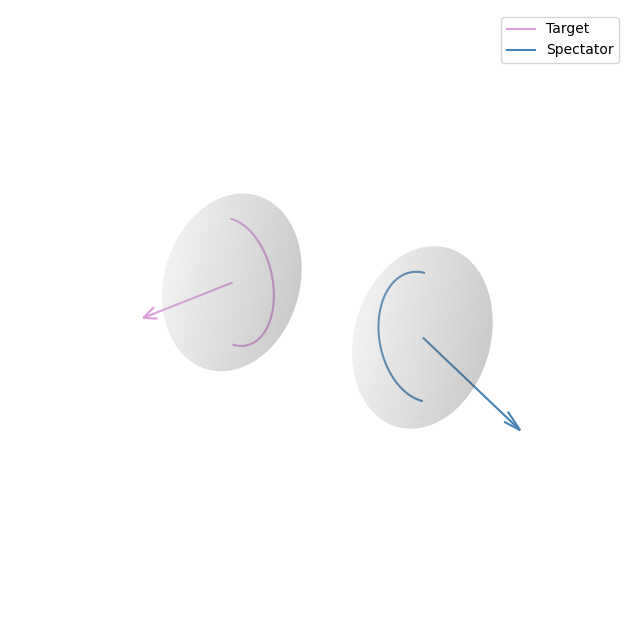

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Generate the Bloch-sphere mesh once
u, v = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)
xs, ys = np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v))
zs      = np.outer(np.ones_like(u), np.cos(v))

# Example trajectories (replace with your real data)
# ------------------------------------------------------------
# Target qubit trajectory
x_t, y_t, z_t = 0.8*xs[0, :], 0.8*ys[0, :], 0.8*zs[0, :]           # dummy
# Spectator qubit trajectory
x_s, y_s, z_s = 0.8*xs[50, :], 0.8*ys[50, :], 0.8*zs[50, :]        # dummy

# ------------------------------------------------------------
fig = plt.figure(figsize=(8, 8))                # square figure
ax  = fig.add_subplot(111, projection='3d')

offset = 1.8                                     # sphere spacing

# Draw the two spheres
ax.plot_surface(xs - offset, ys, zs,
                color='lightgrey', alpha=0.15, linewidth=0)
ax.plot_surface(xs + offset, ys, zs,
                color='lightgrey', alpha=0.15, linewidth=0)

# Plot trajectories (shifted by same offset)
ax.plot(x_t - offset, y_t, z_t,   color='plum',      label='Target')
ax.plot(x_s + offset, y_s, z_s,   color='steelblue', label='Spectator')

# Optional arrows at final points
ax.quiver(-offset, 0, 0, x_t[-1]-offset, y_t[-1], z_t[-1],
          arrow_length_ratio=0.15, color='plum')
ax.quiver( offset, 0, 0, x_s[-1]+offset, y_s[-1], z_s[-1],
          arrow_length_ratio=0.15, color='steelblue')

# Equal axis scaling keeps the spheres round
ax.set_box_aspect((1, 1, 1))      # Matplotlib ≥3.3
ax.set_xlim(-3, 3); ax.set_ylim(-2, 2); ax.set_zlim(-2, 2)

ax.set_axis_off()
ax.legend()
plt.show()